In [1]:
!unzip "Copy of devnagari digit.zip"

Streaming output truncated to the last 5000 lines.
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10299.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10300.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10301.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10302.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10303.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10304.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10306.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/10307.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/104017.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/104018.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/104019.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/104021.png  
  inflating: DevanagariHandwrittenDigitDataset/Train/digit_7/104023.p

Loading training data...
Loading testing data...
Training set: (17000, 28, 28, 1), Labels: (17000, 10)
Testing set: (3000, 28, 28, 1), Labels: (3000, 10)


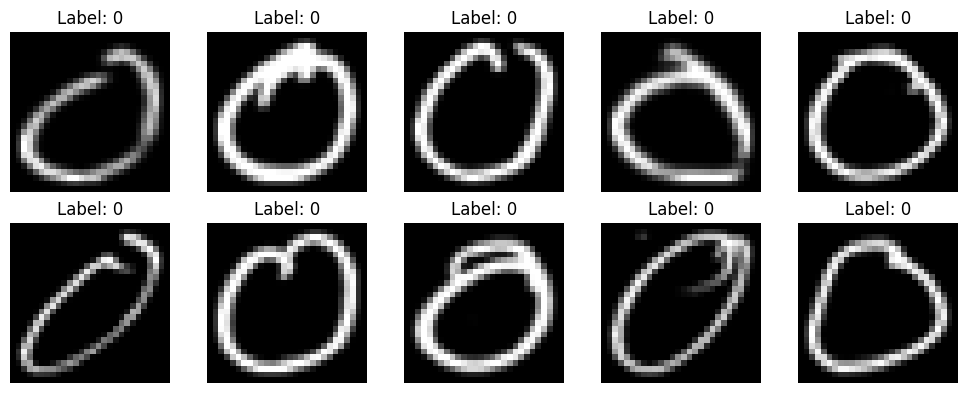

In [2]:
# Import necessary libraries
import os
import numpy as np
import tensorflow as tf
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
from PIL import Image
import warnings
warnings.filterwarnings('ignore')

# Define dataset paths
train_dir = "DevanagariHandwrittenDigitDataset/Train/"
test_dir = "DevanagariHandwrittenDigitDataset/Test/"

# Define image size
img_height, img_width = 28, 28

# Function to load images and labels using PIL
def load_images_from_folder(folder):
    images = []
    labels = []
    class_names = sorted(os.listdir(folder))  # Sorted class names (digit_0, digit_1, ...)
    class_map = {name: i for i, name in enumerate(class_names)}  # Map class names to labels

    for class_name in class_names:
        class_path = os.path.join(folder, class_name)
        label = class_map[class_name]

        for filename in os.listdir(class_path):
            img_path = os.path.join(class_path, filename)

            # Load image using PIL
            img = Image.open(img_path).convert("L")  # Convert to grayscale
            img = img.resize((img_width, img_height))  # Resize to (28,28)
            img = np.array(img) / 255.0  # Normalize pixel values to [0,1]

            images.append(img)
            labels.append(label)

    return np.array(images), np.array(labels)

# Load training and testing datasets
print("Loading training data...")
x_train, y_train = load_images_from_folder(train_dir)
print("Loading testing data...")
x_test, y_test = load_images_from_folder(test_dir)

# Reshape images for Keras input
x_train = x_train.reshape(-1, img_height, img_width, 1)  # Shape (num_samples, 28, 28, 1)
x_test = x_test.reshape(-1, img_height, img_width, 1)

# One-hot encode labels
y_train = to_categorical(y_train, num_classes=10)
y_test = to_categorical(y_test, num_classes=10)

# Print dataset shape
print(f"Training set: {x_train.shape}, Labels: {y_train.shape}")
print(f"Testing set: {x_test.shape}, Labels: {y_test.shape}")

# Visualize some images
plt.figure(figsize=(10, 4))
for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap='gray')
    plt.title(f"Label: {np.argmax(y_train[i])}")
    plt.axis("off")
plt.tight_layout()
plt.show()

In [3]:
# Model parameters
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense, Flatten, Input
from tensorflow.keras.models import Sequential

num_classes = 10
input_shape = (28, 28, 1)

# Build the model
model = Sequential([
    Input(shape=input_shape),
    Flatten(),  # Flatten the 28x28 image to a 784-dimensional vector
    Dense(64, activation="sigmoid"),  # 1st hidden layer: 64 neurons
    Dense(128, activation="sigmoid"),  # 2nd hidden layer: 128 neurons
    Dense(256, activation="sigmoid"),  # 3rd hidden layer: 256 neurons
    Dense(num_classes, activation="softmax")  # Output layer: 10 units with softmax
])

# Display model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        50,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │         8,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 94,154 (367.79 KB)

 Trainable params: 94,154 (367.79 KB)

 Non-trainable params: 0 (0.00 B)

In [4]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Model compiled successfully!")
print(f"Optimizer: Adam")
print(f"Loss function: Categorical Crossentropy")
print(f"Metrics: Accuracy")

Model compiled successfully!
Optimizer: Adam
Loss function: Categorical Crossentropy
Metrics: Accuracy


In [5]:
# Training parameters
batch_size = 128
epochs = 20

# Callbacks
callbacks = [
    keras.callbacks.ModelCheckpoint(filepath="best_model.keras", save_best_only=True, monitor='val_accuracy'),
    keras.callbacks.EarlyStopping(monitor="val_loss", patience=3, restore_best_weights=True)
]

# Train the model
print("Training the model...")
history = model.fit(
    x_train,
    y_train,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print("Training completed!")

Training the model...
Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.4412 - loss: 1.6316 - val_accuracy: 0.0000e+00 - val_loss: 7.3530
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.8448 - loss: 0.5218 - val_accuracy: 0.0000e+00 - val_loss: 8.3786
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9226 - loss: 0.2696 - val_accuracy: 0.0000e+00 - val_loss: 9.0205
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9486 - loss: 0.1831 - val_accuracy: 0.0000e+00 - val_loss: 9.5886
Training completed!


In [6]:
# Evaluate the model on test set
print("Evaluating model on test data...")
test_loss, test_acc = model.evaluate(x_test, y_test, verbose=2)

print(f"\nTest Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.4f}")

Evaluating model on test data...
94/94 - 0s - 2ms/step - accuracy: 0.6123 - loss: 2.1455

Test Loss: 2.1455
Test Accuracy: 0.6123


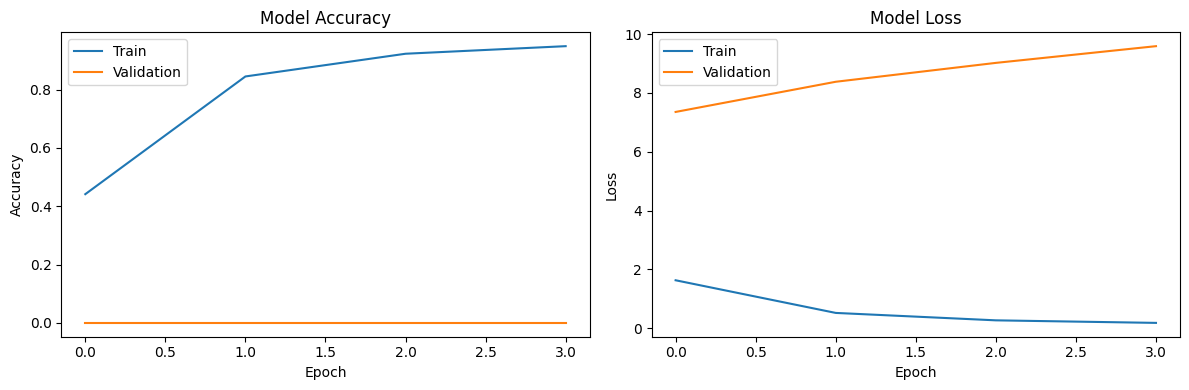

In [7]:
# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')

plt.tight_layout()
plt.show()

In [8]:
# Save the trained model
model.save("devnagari_digit_model.h5")
print("Model saved as 'devnagari_digit_model.h5'")

# Load the saved model
loaded_model = keras.models.load_model("devnagari_digit_model.h5")
print("Model loaded successfully!")

# Re-evaluate the loaded model
print("Re-evaluating loaded model...")
test_loss_loaded, test_acc_loaded = loaded_model.evaluate(x_test, y_test, verbose=2)

print(f"\nLoaded Model - Test Loss: {test_loss_loaded:.4f}")
print(f"Loaded Model - Test Accuracy: {test_acc_loaded:.4f}")

Model saved as 'devnagari_digit_model.h5'
Model loaded successfully!
Re-evaluating loaded model...
94/94 - 1s - 5ms/step - accuracy: 0.6123 - loss: 2.1455

Loaded Model - Test Loss: 2.1455
Loaded Model - Test Accuracy: 0.6123


Making predictions on test data...
94/94 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step


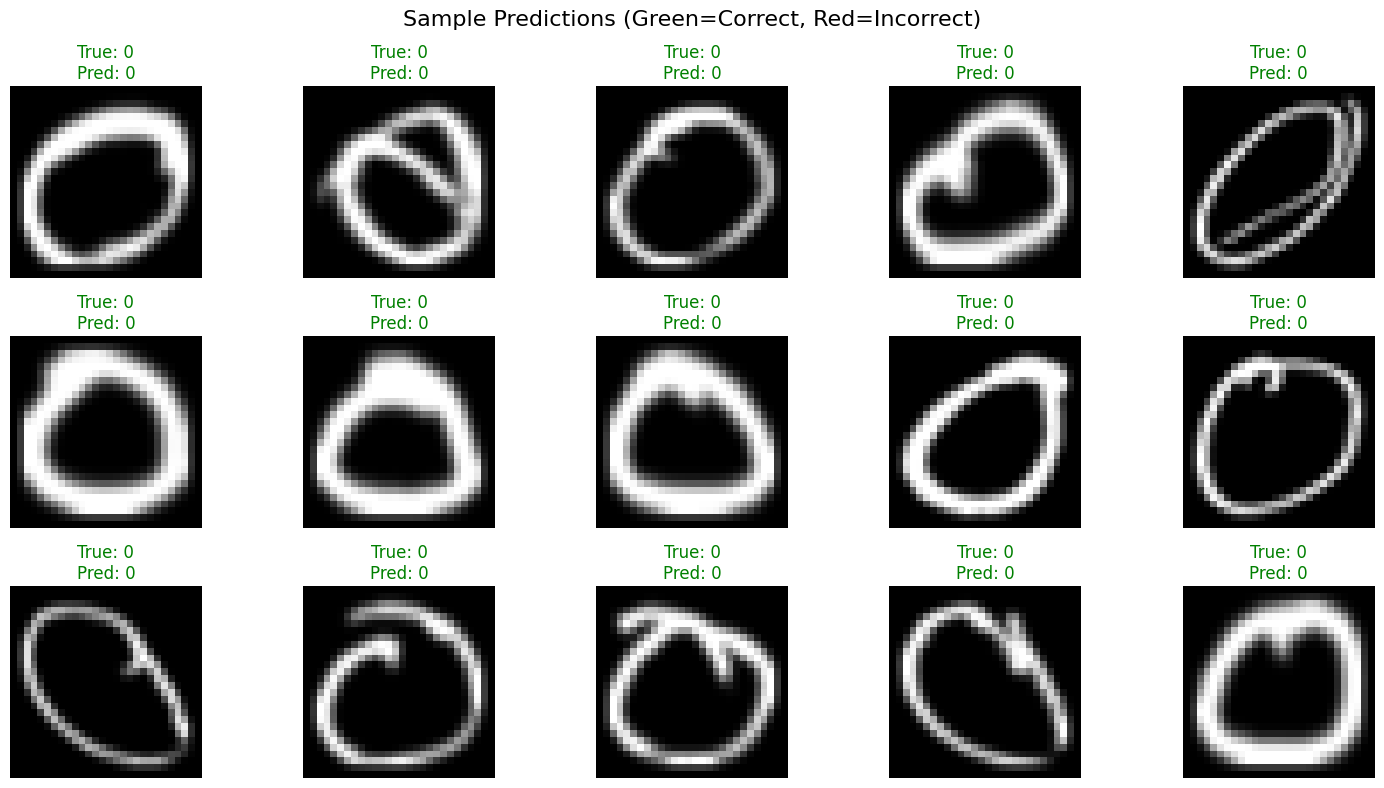

Manual Calculation - Test Accuracy: 0.6123


In [9]:
# Make predictions on test images
print("Making predictions on test data...")
predictions = model.predict(x_test)

# Convert predicted probabilities to digit labels
predicted_labels = np.argmax(predictions, axis=1)
true_labels = np.argmax(y_test, axis=1)

# Display some predictions
plt.figure(figsize=(15, 8))
for i in range(15):
    plt.subplot(3, 5, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')

    # Determine if prediction is correct
    is_correct = predicted_labels[i] == true_labels[i]
    color = 'green' if is_correct else 'red'

    plt.title(f"True: {true_labels[i]}\nPred: {predicted_labels[i]}", color=color)
    plt.axis("off")

plt.suptitle("Sample Predictions (Green=Correct, Red=Incorrect)", fontsize=16)
plt.tight_layout()
plt.show()

# Calculate and display accuracy
accuracy = np.mean(predicted_labels == true_labels)
print(f"Manual Calculation - Test Accuracy: {accuracy:.4f}")

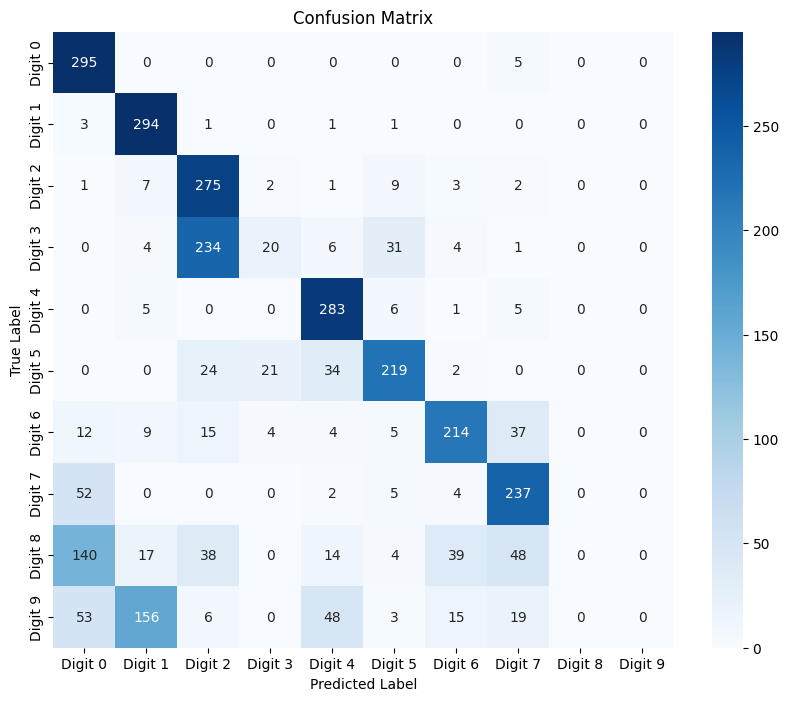


Classification Report:
              precision    recall  f1-score   support

     Digit 0       0.53      0.98      0.69       300
     Digit 1       0.60      0.98      0.74       300
     Digit 2       0.46      0.92      0.62       300
     Digit 3       0.43      0.07      0.12       300
     Digit 4       0.72      0.94      0.82       300
     Digit 5       0.77      0.73      0.75       300
     Digit 6       0.76      0.71      0.74       300
     Digit 7       0.67      0.79      0.72       300
     Digit 8       0.00      0.00      0.00       300
     Digit 9       0.00      0.00      0.00       300

    accuracy                           0.61      3000
   macro avg       0.49      0.61      0.52      3000
weighted avg       0.49      0.61      0.52      3000



In [10]:
# Display confusion matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Create confusion matrix
cm = confusion_matrix(true_labels, predicted_labels)

# Plot confusion matrix
plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[f'Digit {i}' for i in range(10)],
            yticklabels=[f'Digit {i}' for i in range(10)])
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()

# Display classification report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(true_labels, predicted_labels,
                          target_names=[f'Digit {i}' for i in range(10)]))